# Mini-Projet : Système intelligent d’analyse des ventes

Etapes
- Compréhension du problème (Business Understanding)
- Analyse exploratoire des données (EDA)
- Prétraitement des données
- Modélisation Machine Learning
- Évaluation du modèle
- Architecture du système
- Déploiement (MLOps)

##  I. Description du problème

1) Compréhension du problème (Business Understanding)

**Objectifs**

Le système doit :
- analyser les ventes
- prévoir les ventes futures
- détecter les fraudes / anomalies
- être déployé sur Internet

Questions à répondre
- Quelles variables influencent les ventes ?
- Quel indicateur veut-on prédire ?

Exemple : Sales=Quantity×UnitPrice

Donc la variable cible peut être : Sales

## II. Analyse des données

In [38]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from module.utils import *
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

ImportError: attempted relative import with no known parent package

2) Analyse exploratoire des données

In [19]:
df = utils.load_data("../data/online_retail.csv")

NameError: name 'utils' is not defined

In [3]:
# Chargement
df = pd.read_csv("../data/online_retail.csv", encoding="latin1")
df.shape

(541909, 8)

In [4]:
# 5 premiers lignes
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# Structure des données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [6]:
# Stats de bases
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Données dupliquées
df.duplicated().sum()

np.int64(5268)

In [9]:
# Suppression
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(401604, 8)

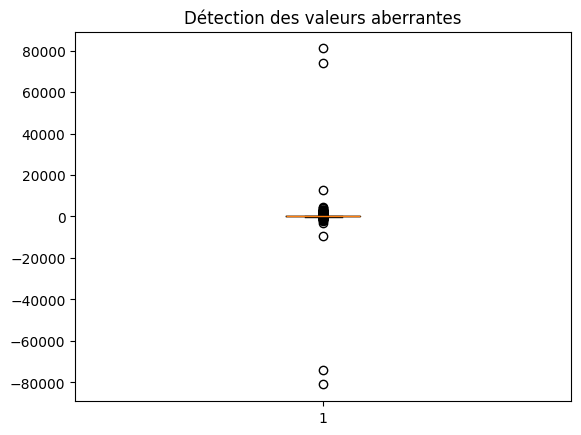

In [11]:
# Boxplot pour outliers
plt.boxplot(df["Quantity"])
plt.title("Détection des valeurs aberrantes")
plt.show()

3) Prétraitement des données

In [12]:
# Feature engineering
df["Sales"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = pd.to_datetime(df["InvoiceDate"]).dt.month
df["Day"] = pd.to_datetime(df["InvoiceDate"]).dt.day
df["Hour"] = pd.to_datetime(df["InvoiceDate"]).dt.hour

## III. Choix des modèles

In [13]:
# Features
X_predict = df[["Quantity", "UnitPrice", "Month", "Day", "Hour"]]
y = df["Sales"]

seed = 42

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_predict, y,
    test_size=0.2,
    random_state=seed
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (321283, 5)
Test shape: (80321, 5)


A) Prédiction des ventes

C’est un problème de régression

Modèles recommandés :
- Random Forest
- XGBoost

Raison :
- XGBoost pour la performance
- Random Forest pour la simplicité

In [14]:
# =========================
# Random Forest
# =========================
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=seed,
    n_jobs=-1 # nombre de processeurs (-1 tout)
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("===== RANDOM FOREST =====")
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)
print("R2   :", rf_r2)

===== RANDOM FOREST =====
RMSE : 597.3347614821253
MAE  : 10.277890434971736
R2   : 0.5001702762981292


In [15]:
# =========================
# XGBoost
# =========================
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("===== XGBOOST =====")
print("RMSE :", xgb_rmse)
print("MAE  :", xgb_mae)
print("R2   :", xgb_r2)

===== XGBOOST =====
RMSE : 678.4688031220514
MAE  : 6.578393371107042
R2   : 0.35516846643317124


### Evaluation

In [16]:
# Comparaison
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rf_rmse, xgb_rmse],
    "MAE": [rf_mae, xgb_mae],
    "R2 Score": [rf_r2, xgb_r2]
})

results

,Model,RMSE,MAE,R2 Score
0,Random Forest,597.334761,10.277890,0.500170
1,XGBoost,678.468803,6.578393,0.355168


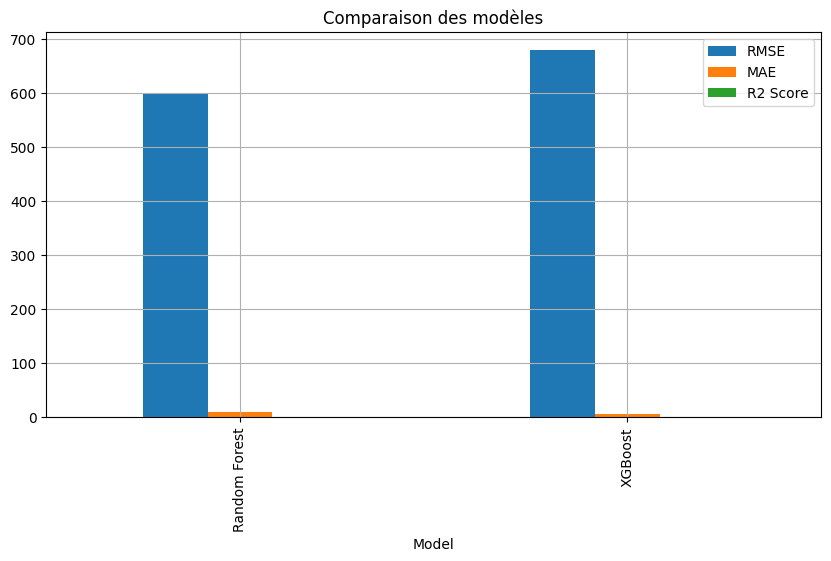

In [17]:
results.plot(
    x="Model",
    y=["RMSE", "MAE", "R2 Score"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparaison des modèles")
plt.grid(True)
plt.show()

- RMSE plus faible → 597 < 678
- R² plus élevé → 0.50 > 0.36

Random Forest est meilleur.

B) Détection d’anomalies

Utiliser :
- Isolation Forest
- Local Outlier Factor

Je recommande :
- Isolation Forest

car très adapté aux fraudes.

In [ ]:
# Features pour détection
X_detect = df[["Quantity", "UnitPrice", "Sales"]]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_detect)

print(X_detect.shape)
df.head()

In [ ]:
iso_model = IsolationForest(
    contamination=0.02,
    random_state=42,
    n_estimators=100
)

df["IF_Prediction"] = iso_model.fit_predict(X_scaled)

# -1 = anomalie
#  1 = normal

if_count = (df["IF_Prediction"] == -1).sum()

print("Anomalies détectées (Isolation Forest):", if_count)

In [ ]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

df["LOF_Prediction"] = lof_model.fit_predict(X_scaled)

lof_count = (df["LOF_Prediction"] == -1).sum()

print("Anomalies détectées (LOF):", lof_count)

### Evaluation

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "Local Outlier Factor"],
    "Nb anomalies": [if_count, lof_count]
})

comparison

In [ ]:
comparison.plot(
    x="Model",
    y="Nb anomalies",
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparaison des modèles d'anomalie")
plt.ylabel("Nombre d'anomalies")
plt.grid(True)
plt.show()

## IV. Architecture du système

CSV / Base de données
        ↓
Prétraitement
        ↓
Modèle ML
        ↓
API FastAPI
        ↓
Interface Streamlit
        ↓
Utilisateur

## V. Proposition de déploiement